In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


def fetch_stock_data(tickers, period="1y", interval="1d"):
    data = yf.download(tickers, period=period, interval=interval)

    # Clean
    data = data.dropna(how='all')

    return data

In [ ]:
tickers = "AAPL TSLA"
data= fetch_stock_data(tickers)
data.head()

/tmp/ipykernel_9351/1306579716.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period=period, interval=interval)
[*********************100%***********************]  2 of 2 completed


Price            Close                    High                     Low  \
Ticker            AAPL        TSLA        AAPL        TSLA        AAPL   
Date                                                                     
2025-04-28  209.228104  285.880005  210.582203  294.859985  206.559741   
2025-04-29  210.293457  292.029999  211.318986  293.320007  207.465770   
2025-04-30  211.577850  282.160004  212.653165  284.450012  205.773148   
2025-05-01  212.394302  280.519989  213.628912  290.869995  207.993470   
2025-05-02  204.458908  287.209991  206.091791  294.779999  201.282748   

Price                         Open                 Volume             
Ticker            TSLA        AAPL        TSLA       AAPL       TSLA  
Date                                                                  
2025-04-28  272.420013  209.088712  288.980011   38743100  151731800  
2025-04-29  279.470001  207.784388  285.500000   36827600  108906600  
2025-04-30  270.779999  208.391740  279.899994   52286500  128961100  
2025-05-01  279.809998  208.172696  280.010010   57365700   99659000  
2025-05-02  279.809998  205.195687  284.899994  101010600  114454700

In [ ]:
close = data['Close']
close.head()

Ticker,AAPL,TSLA
Date,,
2025-04-28,209.228104,285.880005
2025-04-29,210.293457,292.029999
2025-04-30,211.577850,282.160004
2025-05-01,212.394302,280.519989
2025-05-02,204.458908,287.209991


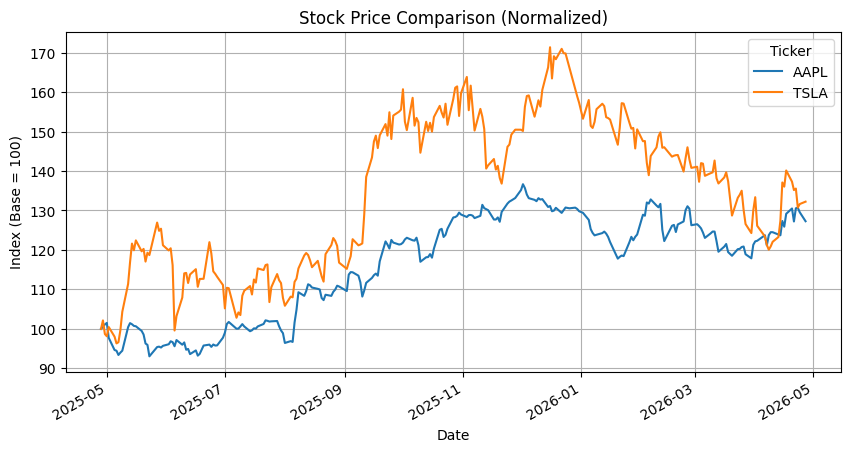

In [ ]:
normalized = close / close.iloc[0] * 100

normalized.plot(figsize=(10,5))

plt.title("Stock Price Comparison (Normalized)")
plt.ylabel("Index (Base = 100)")
plt.grid()
plt.show()

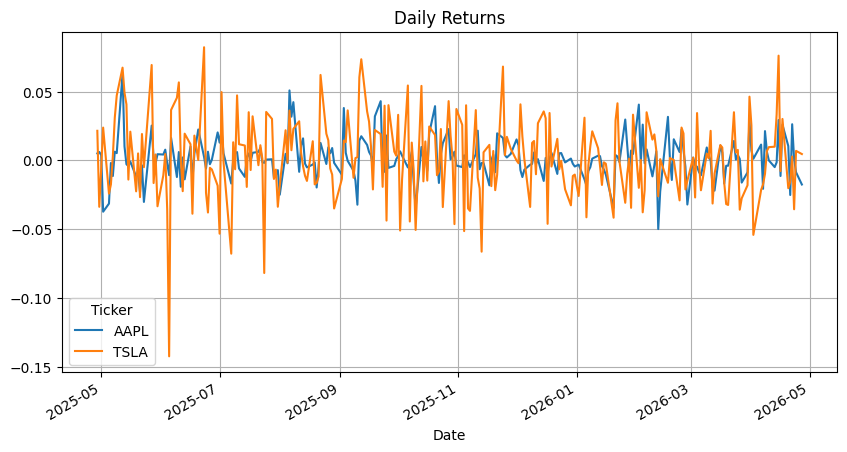

In [ ]:
returns = close.pct_change()

returns.plot(figsize=(10,5))
plt.title("Daily Returns")
plt.grid()
plt.show()

In [ ]:
volatility = returns.std()

print("Volatility:\n", volatility)

Volatility:
 Ticker
AAPL    0.014807
TSLA    0.029850
dtype: float64


TSLA is more volatile

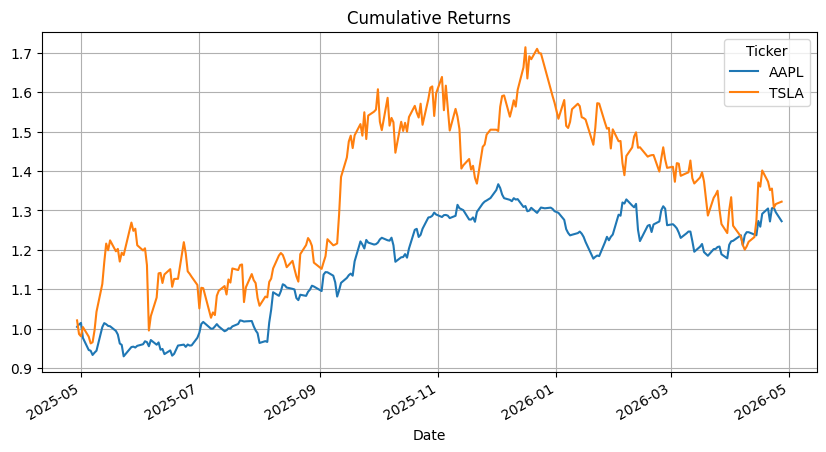

In [ ]:
cumulative_returns = (1 + returns).cumprod()

cumulative_returns.plot(figsize=(10,5))
plt.title("Cumulative Returns")
plt.grid()
plt.show()

In [ ]:
aapl = yf.Ticker("AAPL")

income = aapl.financials

metrics = income.loc[['Total Revenue', 'EBIT', 'Net Income']]

metrics = metrics.dropna(axis=1) / 1e9
metrics

,2025-09-30,2024-09-30,2023-09-30,2022-09-30
Total Revenue,416.161,391.035,383.285,394.328
EBIT,133.050,123.216,114.301,119.437
Net Income,112.010,93.736,96.995,99.803


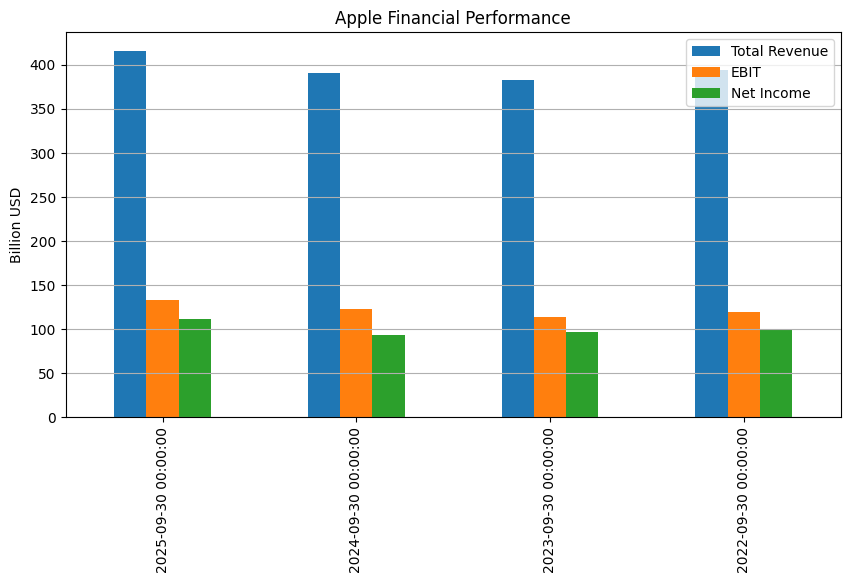

In [ ]:
metrics.T.plot(kind='bar', figsize=(10,5))

plt.title("Apple Financial Performance")
plt.ylabel("Billion USD")
plt.grid(axis='y')
plt.show()

In [ ]:
revenue = income.loc['Total Revenue']
net_income = income.loc['Net Income']

profit_margin = (net_income / revenue) * 100

print(profit_margin)

2025-09-30    26.915064
2024-09-30    23.971256
2023-09-30    25.306234
2022-09-30    25.309641
2021-09-30          NaN
dtype: float64


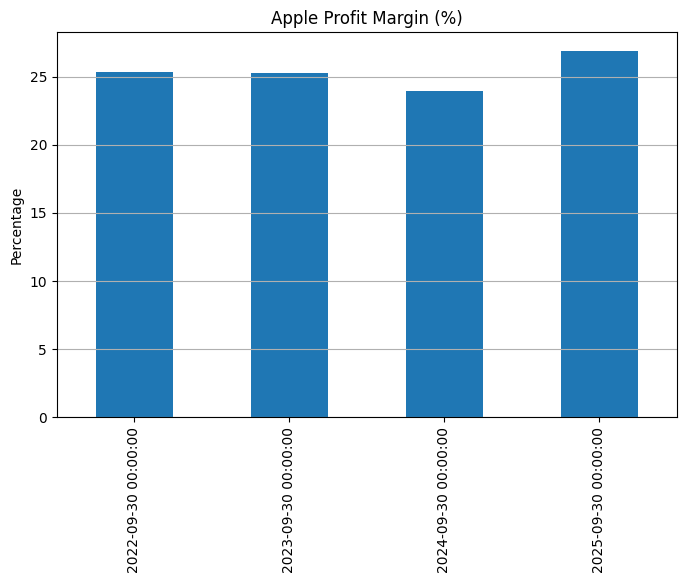

In [ ]:
profit_margin = profit_margin.dropna().sort_index()

profit_margin.plot(kind='bar', figsize=(8,5))

plt.title("Apple Profit Margin (%)")
plt.ylabel("Percentage")
plt.grid(axis='y')

plt.show()

Apple Inc. maintains a strong and stable profit margin ranging between 24% and 27% over recent years. This indicates efficient cost management and a strong pricing strategy. The increase in profit margin in 2025 suggests improved operational performance and profitability.

In [ ]:
aapl = yf.Ticker("AAPL")
tsla = yf.Ticker("TSLA")

In [ ]:
# Apple
aapl_income = aapl.financials
aapl_pm = (aapl_income.loc['Net Income'] / aapl_income.loc['Total Revenue']) * 100

# Tesla
tsla_income = tsla.financials
tsla_pm = (tsla_income.loc['Net Income'] / tsla_income.loc['Total Revenue']) * 100

# Combine
pm_df = pd.DataFrame({
    "Apple": aapl_pm,
    "Tesla": tsla_pm
})

pm_df

,Apple,Tesla
2021-09-30,NaN,NaN
2021-12-31,NaN,NaN
2022-09-30,25.309641,NaN
2022-12-31,NaN,15.446466
2023-09-30,25.306234,NaN
2023-12-31,NaN,15.499158
2024-09-30,23.971256,NaN
2024-12-31,NaN,7.298598
2025-09-30,26.915064,NaN
2025-12-31,NaN,4.000970


In [ ]:
pm_df.index = pm_df.index.year

In [ ]:
pm_df = pm_df.groupby(pm_df.index).mean()
pm_df

,Apple,Tesla
2021,NaN,NaN
2022,25.309641,15.446466
2023,25.306234,15.499158
2024,23.971256,7.298598
2025,26.915064,4.000970


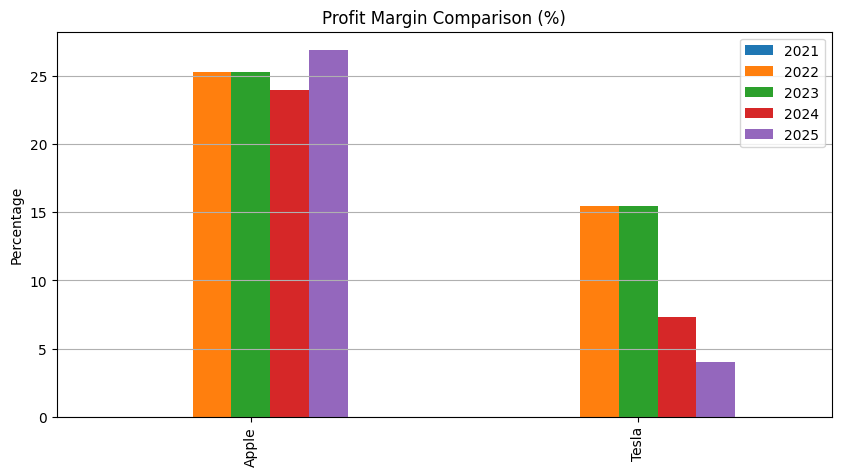

In [ ]:
pm_df.T.plot(kind='bar', figsize=(10,5))
import matplotlib.pyplot as plt

plt.title("Profit Margin Comparison (%)")
plt.ylabel("Percentage")
plt.grid(axis='y')
plt.show()

A comparative analysis of profit margins shows that Apple maintains strong and consistent profitability, with margins above 24% across all observed years. In contrast, Tesla’s profit margin has declined significantly from over 15% to approximately 4%, indicating increased cost pressures and a growth-focused strategy. This highlights the difference between a mature, efficiency-driven company and a growth-oriented company.

In [ ]:
# Price Return
prices = yf.download("AAPL TSLA", period="1y")['Close']

returns = prices.pct_change()

total_returns = (prices.iloc[-1] / prices.iloc[0] - 1) * 100
volatility = returns.std() * (252 ** 0.5)

/tmp/ipykernel_9351/3462307059.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download("AAPL TSLA", period="1y")['Close']
[*********************100%***********************]  2 of 2 completed


In [ ]:
# Profit Margin
aapl_pm = (aapl.financials.loc['Net Income'] / aapl.financials.loc['Total Revenue']).mean()
tsla_pm = (tsla.financials.loc['Net Income'] / tsla.financials.loc['Total Revenue']).mean()

In [ ]:
dashboard = pd.DataFrame({
    "Metric": ["Profit Margin (%)", "Annual Return (%)", "Volatility"],
    "Apple": [
        aapl_pm * 100,
        total_returns['AAPL'],
        volatility['AAPL']
    ],
    "Tesla": [
        tsla_pm * 100,
        total_returns['TSLA'],
        volatility['TSLA']
    ]
})

dashboard

,Metric,Apple,Tesla
0,Profit Margin (%),25.375549,10.561298
1,Annual Return (%),27.215181,32.300264
2,Volatility,0.235096,0.473855


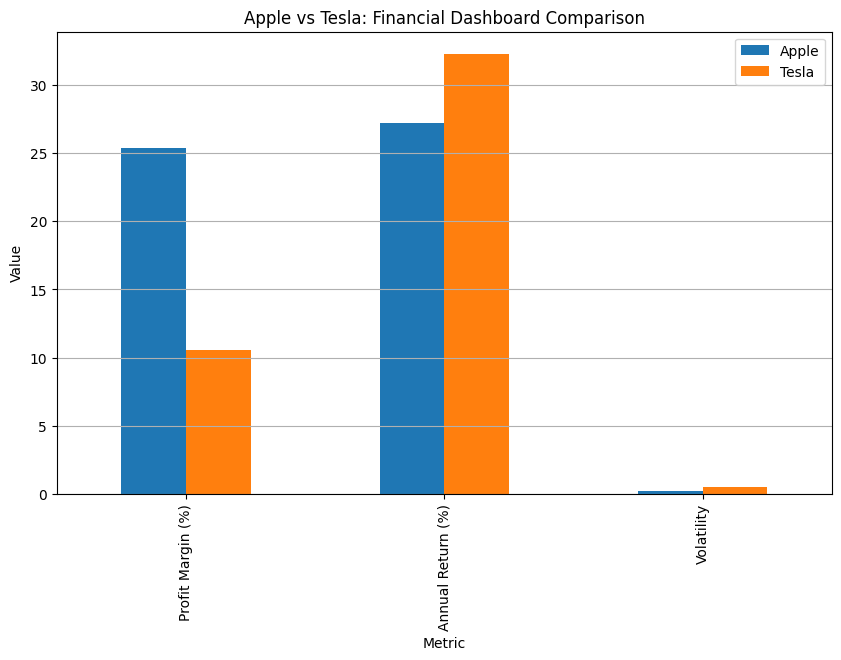

In [ ]:
dashboard.set_index("Metric").plot(kind='bar', figsize=(10,6))

plt.title("Apple vs Tesla: Financial Dashboard Comparison")
plt.ylabel("Value")
plt.grid(axis='y')
plt.show()

I compared Apple and Tesla across profitability, returns, and risk. I found that Apple is more stable and profitable, while Tesla offers higher returns but with significantly higher volatility. This helped me understand the trade-off between risk and return in equity markets.